In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Q1 

## a. Create a CSV file with sample data.

In [4]:
df = [{"Temp": 50, "Yield": 3.3},
    {"Temp": 50, "Yield": 2.8},
    {"Temp": 50, "Yield": 2.9},
    {"Temp": 70, "Yield": 2.3},
    {"Temp": 70, "Yield": 2.6},
    {"Temp": 70, "Yield": 2.1},
    {"Temp": 80, "Yield": 2.5},
    {"Temp": 80, "Yield": 2.9},
    {"Temp": 80, "Yield": 2.4},
    {"Temp": 90, "Yield": 3.0},
    {"Temp": 90, "Yield": 3.1},
    {"Temp": 90, "Yield": 2.8},
    {"Temp": 100, "Yield": 3.3},
    {"Temp": 100, "Yield": 3.5},
    {"Temp": 100, "Yield": 3.0}]

df = pd.DataFrame(df)
df.to_csv("yield_data.csv", index=False)
df.head()

,Temp,Yield
0,50,3.3
1,50,2.8
2,50,2.9
3,70,2.3
4,70,2.6


## b. Write a Python function program to:
## Find the fitted simple linear and polynomial regression equations for the given data.

# 1) Simple Linear Regression

## a. Manual Method

In [8]:
x=df["Temp"].values
y=df["Yield"].values

n=len(x)

x_mean = np.mean(x)
y_mean = np.mean(y)

b1=np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
b0=y_mean-b1*x_mean

print("b0 =", b0)
print("b1 =", b1)

b0 = 2.306306306306306
b1 = 0.006756756756756758


## b. Matrix Method

In [10]:
A=np.array([[ n, df['Temp'].sum()],[df['Temp'].sum(), (df['Temp']**2).sum()]])
B=np.array([[df['Yield'].sum()], [(df['Temp']*df['Yield']).sum()]])

coefficients=np.linalg.inv(A)@B
b0=coefficients[0][0]
b1=coefficients[1][0]
print("b0 =", b0)
print("b1 =", b1)

b0 = 2.3063063063062974
b1 = 0.006756756756756936


## c. Thus, coefficients are same using both methods

## e. Error, MSE, RMSE

In [13]:
df['Predicted']=round(b0+b1*df['Temp'],1)
df['Predicted-Actual']=(df['Predicted']-df['Yield'])

df

,Temp,Yield,Predicted,Predicted-Actual
0,50,3.3,2.6,-0.7
1,50,2.8,2.6,-0.2
2,50,2.9,2.6,-0.3
3,70,2.3,2.8,0.5
4,70,2.6,2.8,0.2
5,70,2.1,2.8,0.7
6,80,2.5,2.8,0.3
7,80,2.9,2.8,-0.1
8,80,2.4,2.8,0.4
9,90,3.0,2.9,-0.1


In [14]:
mse=(df['Predicted-Actual']**2).sum()/n
rmse=math.sqrt(mse)
print('MSE = ', mse)
print('RMSE = ', rmse)

MSE =  0.13733333333333325
RMSE =  0.37058512292499446


# 2) Polynomial Regression (Quadratic)

In [16]:
X_poly = np.column_stack((np.ones(n), x, x**2))

beta_poly = np.linalg.inv(X_poly.T @ X_poly)@X_poly.T@y

b0_poly=beta_poly[0]
b1_poly=beta_poly[1]
b2_poly=beta_poly[2]

print("b0 =", b0_poly)
print("b1 =", b1_poly)
print("b2 =", b2_poly)

b0 = 7.960481099653949
b1 = -0.15371134020614519
b2 = 0.0010756013745702197


In [17]:
df['Quadratic Predicted']=b0_poly+b1_poly*df['Temp']+b2_poly*(df['Temp']**2)
df[['Temp','Yield','Predicted','Quadratic Predicted']]

,Temp,Yield,Predicted,Quadratic Predicted
0,50,3.3,2.6,2.963918
1,50,2.8,2.6,2.963918
2,50,2.9,2.6,2.963918
3,70,2.3,2.8,2.471134
4,70,2.6,2.8,2.471134
5,70,2.1,2.8,2.471134
6,80,2.5,2.8,2.547423
7,80,2.9,2.8,2.547423
8,80,2.4,2.8,2.547423
9,90,3.0,2.9,2.838832


## e. Error, MSE, RMSE

In [19]:
df['Quadratic-Actual']=df['Quadratic Predicted']-df['Yield']
mse=(df['Quadratic-Actual']**2).sum()/n
rmse=math.sqrt(mse)
print('MSE = ', mse)
print('RMSE = ', rmse)

MSE =  0.047784650630011485
RMSE =  0.2185970050801508


## d. Plot the scatterplot of the raw data and then another scatterplot with lines pertaining to a linear fit and a quadratic fit overlayed.

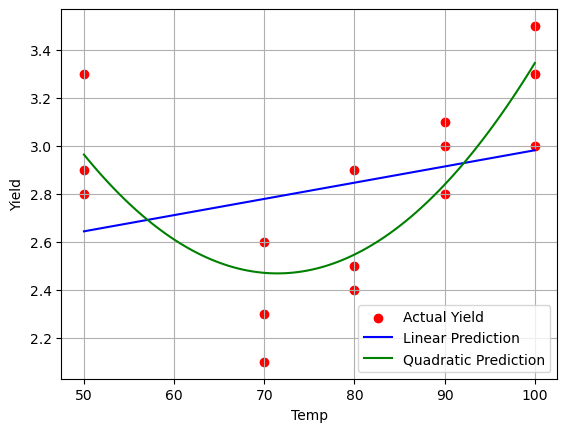

In [21]:
plt.scatter(x=df['Temp'], y=df['Yield'], color='red', label='Actual Yield')

x_line=np.linspace(df['Temp'].min(), df['Temp'].max(), 100)
plt.plot(x_line, b0+b1*x_line, color='blue', label='Linear Prediction')
plt.plot(x_line, b0_poly+b1_poly*x_line+b2_poly*(x_line**2), color='green', label='Quadratic Prediction')

plt.xlabel('Temp')
plt.ylabel('Yield')
plt.legend(loc='lower right')
plt.grid()

plt.show()

# Q2

## a. Create a CSV file with sample data.

In [24]:
df2 = [{"Infarct": 0.119, "Risk": 0.34, "X2": 0, "X3": 0},
    {"Infarct": 0.190, "Risk": 0.64, "X2": 0, "X3": 0},
    {"Infarct": 0.395, "Risk": 0.76, "X2": 0, "X3": 0},
    {"Infarct": 0.469, "Risk": 0.83, "X2": 0, "X3": 0},
    {"Infarct": 0.130, "Risk": 0.73, "X2": 0, "X3": 0},
    {"Infarct": 0.311, "Risk": 0.82, "X2": 0, "X3": 0},
    {"Infarct": 0.418, "Risk": 0.95, "X2": 0, "X3": 0},
    {"Infarct": 0.480, "Risk": 1.06, "X2": 0, "X3": 0},
    {"Infarct": 0.687, "Risk": 1.20, "X2": 0, "X3": 0},
    {"Infarct": 0.847, "Risk": 1.47, "X2": 0, "X3": 0},
    {"Infarct": 0.062, "Risk": 0.44, "X2": 1, "X3": 0},
    {"Infarct": 0.122, "Risk": 0.77, "X2": 1, "X3": 0},
    {"Infarct": 0.033, "Risk": 0.90, "X2": 1, "X3": 0},
    {"Infarct": 0.102, "Risk": 1.07, "X2": 1, "X3": 0},
    {"Infarct": 0.206, "Risk": 1.01, "X2": 1, "X3": 0},
    {"Infarct": 0.249, "Risk": 1.03, "X2": 1, "X3": 0},
    {"Infarct": 0.220, "Risk": 1.16, "X2": 1, "X3": 0},
    {"Infarct": 0.299, "Risk": 1.21, "X2": 1, "X3": 0},
    {"Infarct": 0.350, "Risk": 1.20, "X2": 1, "X3": 0},
    {"Infarct": 0.350, "Risk": 1.22, "X2": 1, "X3": 0},
    {"Infarct": 0.588, "Risk": 0.99, "X2": 1, "X3": 0},
    {"Infarct": 0.379, "Risk": 0.77, "X2": 0, "X3": 1},
    {"Infarct": 0.149, "Risk": 1.05, "X2": 0, "X3": 1},
    {"Infarct": 0.316, "Risk": 1.06, "X2": 0, "X3": 1},
    {"Infarct": 0.390, "Risk": 1.02, "X2": 0, "X3": 1},
    {"Infarct": 0.429, "Risk": 0.99, "X2": 0, "X3": 1},
    {"Infarct": 0.477, "Risk": 0.97, "X2": 0, "X3": 1},
    {"Infarct": 0.439, "Risk": 1.12, "X2": 0, "X3": 1},
    {"Infarct": 0.446, "Risk": 1.23, "X2": 0, "X3": 1},
    {"Infarct": 0.538, "Risk": 1.19, "X2": 0, "X3": 1},
    {"Infarct": 0.625, "Risk": 1.22, "X2": 0, "X3": 1},
    {"Infarct": 0.974, "Risk": 1.40, "X2": 0, "X3": 1}]

df3=pd.DataFrame(df2)
df3.to_csv("heart_attack_data.csv", index=False)

df3.head()

,Infarct,Risk,X2,X3
0,0.119,0.34,0,0
1,0.190,0.64,0,0
2,0.395,0.76,0,0
3,0.469,0.83,0,0
4,0.130,0.73,0,0


## Matrix Method

In [26]:
A=np.array([[len(df3), df3['Risk'].sum(), df3['X2'].sum(), df3['X3'].sum()],
              [df3['Risk'].sum(), (df3['Risk']**2).sum(), (df3['Risk']*df3['X2']).sum(), (df3['Risk']*df3['X3']).sum()],
              [df3['X2'].sum(), (df3['Risk']*df3['X2']).sum(), (df3['X2']**2).sum(), (df3['X2']*df3['X3']).sum()],
              [df3['X3'].sum(), (df3['Risk']*df3['X3']).sum(), (df3['X2']*df3['X3']).sum(), (df3['X3']**2).sum()]])

B=np.array([[df3['Infarct'].sum()], [(df3['Infarct']*df3['Risk']).sum()], [(df3['Infarct']*df3['X2']).sum()], [(df3['Infarct']*df3['X3']).sum()]])

coefficients=np.linalg.inv(A)@B
b0=coefficients[0][0]
b1=coefficients[1][0]
b2=coefficients[2][0]
b3=coefficients[3][0]

print('b0 = ', b0)
print('b1 = ', b1)
print('b2 = ', b2)
print('b3 = ', b3)

b0 =  -0.13453637823601117
b1 =  0.6126549752681942
b2 =  -0.24348223339581976
b3 =  -0.06565569473887084


## e. Plot

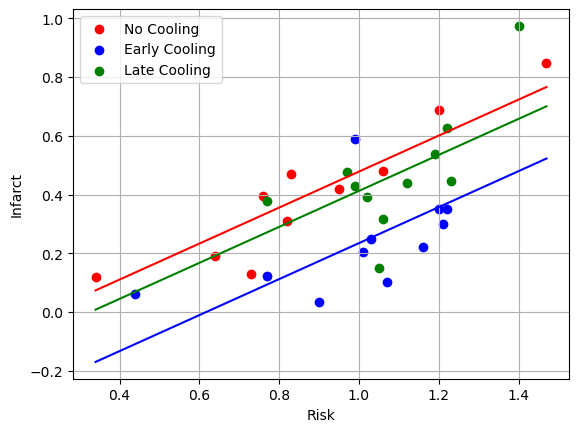

In [28]:
no_cooling=df3[(df3["X2"]==0) & (df3["X3"]==0)]
early_cooling=df3[df3["X2"]==1]
late_cooling=df3[df3["X3"]==1]

plt.scatter(
    no_cooling["Risk"],
    no_cooling["Infarct"],
    color="red",
    label="No Cooling"
)

plt.scatter(
    early_cooling["Risk"],
    early_cooling["Infarct"],
    color="blue",
    label="Early Cooling"
)

plt.scatter(
    late_cooling["Risk"],
    late_cooling["Infarct"],
    color="green",
    label="Late Cooling"
)


x_line=np.linspace(df3['Risk'].min(), df3['Risk'].max(), 100)

# No cooling: X2=0, X3=0
y_no=b0+b1*x_line

# Early cooling: X2=1, X3=0
y_early=b0+b1*x_line+b2

# Late cooling: X2=0, X3=1
y_late=b0+b1*x_line+b3

plt.plot(x_line, y_no, color='red')
plt.plot(x_line, y_early, color='blue')
plt.plot(x_line, y_late, color='green')

plt.xlabel('Risk')
plt.ylabel('Infarct')
plt.legend(loc='upper left')
plt.grid()

plt.show()

# Additional

## Q1

In [31]:
from sklearn.linear_model import LinearRegression

data={"Year": [1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973,
        1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
        1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
        1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
        2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
        2019, 2020, 2021, 2022],
        
        "Price": [72, 84, 103, 162, 176, 184, 193, 202, 279,
        506, 540, 432, 486, 685, 937, 1330, 1800, 1645,
        1800, 1970, 2130, 2140, 2570, 3130, 3140, 3200, 3466,
        4334, 4140, 4598, 4680, 5160, 4725, 4045, 4234, 4400,
        4300, 4990, 5600, 5850, 7000, 8400, 10800, 12500, 14500,
        18500, 26400, 31050, 29600, 28006, 26343, 28623, 29667,
        31438, 35220, 48651, 50045, 52950]}

df4=pd.DataFrame(data)

df4.to_csv("gold_price.csv", index=False)

df4.head()

,Year,Price
0,1965,72
1,1966,84
2,1967,103
3,1968,162
4,1969,176


In [32]:
x_mean=df4['Year'].mean()
y_mean=df4['Price'].mean()

b1=(((df4['Year']-x_mean)*(df4['Price']-y_mean)).sum())/((df4['Year']-x_mean)**2).sum()
b0=y_mean-b1*x_mean

print("B0 =", b0)
print("B1 =", b1)

df4['Predicted']=b0+b1*df4['Year']
df4.head()

B0 = -1336226.704266511
B1 = 675.343658679135


,Year,Price,Predicted
0,1965,72,-9176.414962
1,1966,84,-8501.071303
2,1967,103,-7825.727645
3,1968,162,-7150.383986
4,1969,176,-6475.040327


In [33]:
mse=((df4['Predicted']-df4['Price'])**2).sum()/len(df4)
rmse=math.sqrt(mse)
print("MSE =",mse)
print("RMSE =",rmse)

MSE = 62644360.72375505
RMSE = 7914.819058181623


In [34]:
X=df4["Year"].values
Y=df4["Price"].values

X_sklearn=X.reshape(-1, 1)

model=LinearRegression()
model.fit(X_sklearn, Y)

sk_b0=model.intercept_
sk_b1=model.coef_[0]

print("SKLEARN")
print("b0 =", sk_b0)
print("b1 =", sk_b1)

print("\nComparison")
print("Manual b0  =", b0)
print("Sklearn b0 =", sk_b0)

print("\nManual b1  =", b1)
print("Sklearn b1 =", sk_b1)

print('\nPrice of 1g Gold in 2026 (Manual):', (b0+b1*2026)/10)
print('Price of 1g Gold in 2026 (Sklearn):', (sk_b0+sk_b1*2026)/10)

SKLEARN
b0 = -1336226.704266511
b1 = 675.343658679135

Comparison
Manual b0  = -1336226.704266511
Sklearn b0 = -1336226.704266511

Manual b1  = 675.343658679135
Sklearn b1 = 675.343658679135

Price of 1g Gold in 2026 (Manual): 3201.954821741674
Price of 1g Gold in 2026 (Sklearn): 3201.954821741674


## 2. Consider the Question no 1 gold price with following year-wise silver price. Create a CSV file and  
## Write a python program to find the fitted multiple linear regression equation for the given data.  
## Compare the coefficients obtained from sklearn model with your program. Compute the error, MSE and RMSE. Predict the gold and silver price with the year 2026 for 1 gram.**

In [53]:
gold_data = {
    1981: 1800,
    1982: 1645,
    1983: 1800,
    1984: 1970,
    1985: 2130,
    1986: 2140,
    1987: 2570,
    1988: 3130,
    1989: 3140,
    1990: 3200,
    1991: 3466,
    1992: 4334,
    1993: 4140,
    1994: 4598,
    1995: 4680,
    1996: 5160,
    1997: 4725,
    1998: 4045,
    1999: 4234,
    2000: 4400,
    2001: 4300,
    2002: 4990,
    2003: 5600,
    2004: 5850,
    2005: 7000,
    2006: 8400,
    2007: 10800,
    2008: 12500,
    2009: 14500,
    2010: 18500,
    2011: 26400,
    2012: 31050,
    2013: 29600,
    2014: 28006,
    2015: 26343,
    2016: 28623,
    2017: 29667,
    2018: 31438,
    2019: 35220,
    2020: 48651,
    2021: 50045,
    2022: 52950
}

silver_data = {
    1981: 2715,
    1982: 2720,
    1983: 3105,
    1984: 3570,
    1985: 3955,
    1986: 4015,
    1987: 4794,
    1988: 6066,
    1989: 6755,
    1990: 6463,
    1991: 6646,
    1992: 8040,
    1993: 5489,
    1994: 7124,
    1995: 6335,
    1996: 7346,
    1997: 7345,
    1998: 8560,
    1999: 7615,
    2000: 7900,
    2001: 7215,
    2002: 7875,
    2003: 7695,
    2004: 11770,
    2005: 10675,
    2006: 17405,
    2007: 19520,
    2008: 23625,
    2009: 22165,
    2010: 27255,
    2011: 56900,
    2012: 56290,
    2013: 54030,
    2014: 43070,
    2015: 37825,
    2016: 36990,
    2017: 37825,
    2018: 41400,
    2019: 40600,
    2020: 63435,
    2021: 62572,
    2022: 55100
}

years = sorted(silver_data.keys())

df5 = pd.DataFrame({
    "Year": years,
    "Gold_Price": [gold_data[year] for year in years],
    "Silver_Price": [silver_data[year] for year in years]
})

# Save CSV
df5.to_csv("gold_silver_price.csv", index=False)

df5.head()

,Year,Gold_Price,Silver_Price
0,1981,1800,2715
1,1982,1645,2720
2,1983,1800,3105
3,1984,1970,3570
4,1985,2130,3955


In [55]:
def multiple_linear_regression(X, Y):

    X_matrix = np.column_stack((np.ones(len(X)), X))

    beta = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ Y

    return beta

In [57]:
X = df5["Year"].values

Y = df5[["Gold_Price", "Silver_Price"]].values

beta = multiple_linear_regression(X, Y)

print(beta)

[[-2.08401999e+06 -2.75915088e+06]
 [ 1.04810177e+03  1.38874573e+03]]


In [59]:
from sklearn.linear_model import LinearRegression

# sklearn model
model = LinearRegression()

# sklearn expects X to be 2D
X_sklearn = df5[["Year"]]

Y_sklearn = df5[["Gold_Price", "Silver_Price"]]

model.fit(X_sklearn, Y_sklearn)

# Coefficients
sklearn_intercept = model.intercept_
sklearn_slope = model.coef_.flatten()

print("Sklearn Intercept:")
print(sklearn_intercept)

print("\nSklearn Slope:")
print(sklearn_slope)

Sklearn Intercept:
[-2084019.98752127 -2759150.87937228]

Sklearn Slope:
[1048.10177457 1388.74572563]


In [61]:
comparison = pd.DataFrame({
    "Coefficient": [
        "Gold Intercept",
        "Gold Slope",
        "Silver Intercept",
        "Silver Slope"
    ],

    "Program": [
        beta[0, 0],
        beta[1, 0],
        beta[0, 1],
        beta[1, 1]
    ],

    "Sklearn": [
        sklearn_intercept[0],
        sklearn_slope[0],
        sklearn_intercept[1],
        sklearn_slope[1]
    ]
})

comparison.round(6)

,Coefficient,Program,Sklearn
0,Gold Intercept,-2.084020e+06,-2.084020e+06
1,Gold Slope,1.048102e+03,1.048102e+03
2,Silver Intercept,-2.759151e+06,-2.759151e+06
3,Silver Slope,1.388746e+03,1.388746e+03


In [63]:
# Predictions using our coefficients
X_matrix = np.column_stack((
    np.ones(len(X)),
    X
))

Y_pred = X_matrix @ beta

# Actual values
Y_actual = Y

# Errors
error = Y_actual - Y_pred

In [69]:
df5["Gold_Predicted"] = Y_pred[:, 0]
df5["Gold_Error"] = error[:, 0]

df5["Silver_Predicted"] = Y_pred[:, 1]
df5["Silver_Error"] = error[:, 1]

df5.round(2).head()

,Year,Gold_Price,Silver_Price,Gold_Predicted,Gold_Error,Silver_Predicted,Silver_Error
0,1981,1800,2715,-7730.37,9530.37,-8045.60,10760.60
1,1982,1645,2720,-6682.27,8327.27,-6656.85,9376.85
2,1983,1800,3105,-5634.17,7434.17,-5268.11,8373.11
3,1984,1970,3570,-4586.07,6556.07,-3879.36,7449.36
4,1985,2130,3955,-3537.96,5667.96,-2490.61,6445.61


In [71]:
year_2026 = np.array([[1, 2026]])

prediction_2026 = year_2026 @ beta

gold_2026 = prediction_2026[0, 0]
silver_2026 = prediction_2026[0, 1]

print("Gold price in 2026 =", gold_2026)
print("Silver price in 2026 =", silver_2026)

Gold price in 2026 = 39434.20776266302
Silver price in 2026 = 54447.96075401548


## 3. Suppose you have a gold/silver price dataset with a single independent variable (X) and a dependent variable (Y). You want to fit a polynomial regression model to this data. Implement the process of selecting the appropriate degree for the polynomial (e.g., linear, quadratic, cubic) based on the dataset using Python

In [86]:
X = df4["Year"].values
Y = df4["Price"].values

In [88]:
def polynomial_regression(X, Y, degree):

    # Create polynomial features
    X_matrix = np.column_stack(
        [X ** i for i in range(degree + 1)]
    )

    # Normal equation
    beta = np.linalg.inv(
        X_matrix.T @ X_matrix
    ) @ X_matrix.T @ Y

    return beta

In [90]:
def polynomial_predict(X, beta):

    degree = len(beta) - 1

    X_matrix = np.column_stack(
        [X ** i for i in range(degree + 1)]
    )

    return X_matrix @ beta

In [92]:
def calculate_mse(Y_actual, Y_pred):

    error = Y_actual - Y_pred

    MSE = np.mean(error ** 2)

    RMSE = np.sqrt(MSE)

    return MSE, RMSE

In [94]:
results = []

for degree in [1, 2, 3]:

    beta = polynomial_regression(X, Y, degree)

    Y_pred = polynomial_predict(X, beta)

    MSE, RMSE = calculate_mse(Y, Y_pred)

    results.append([
        degree,
        MSE,
        RMSE
    ])


results_df = pd.DataFrame(
    results,
    columns=["Degree", "MSE", "RMSE"]
)

results_df

,Degree,MSE,RMSE
0,1,6.264436e+07,7914.819058
1,2,1.619794e+07,4024.666177
2,3,1.619794e+07,4024.666177


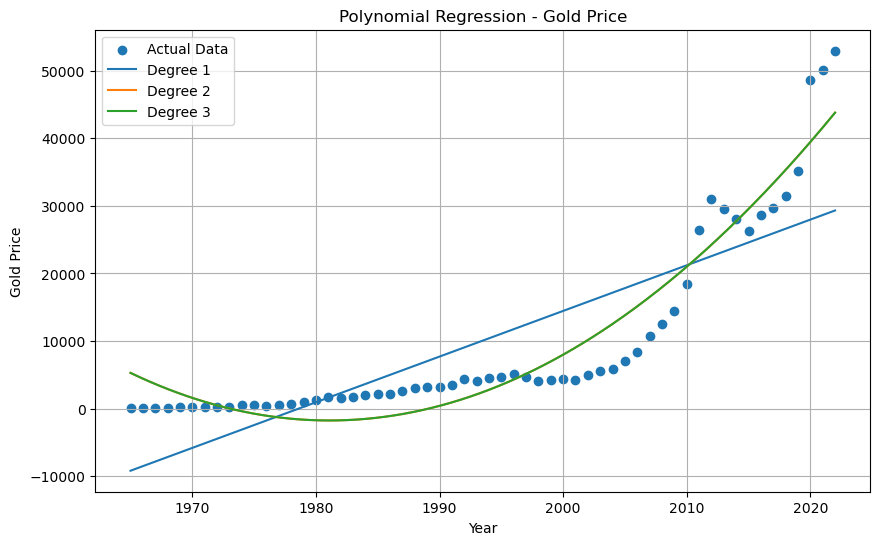

In [96]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    Y,
    label="Actual Data"
)

X_smooth = np.linspace(
    X.min(),
    X.max(),
    300
)

for degree in [1, 2, 3]:

    beta = polynomial_regression(
        X,
        Y,
        degree
    )

    Y_smooth = polynomial_predict(
        X_smooth,
        beta
    )

    plt.plot(
        X_smooth,
        Y_smooth,
        label=f"Degree {degree}"
    )

plt.xlabel("Year")
plt.ylabel("Gold Price")
plt.title("Polynomial Regression - Gold Price")
plt.legend()
plt.grid(True)

plt.show()